# 00 - Math Foundations for Deep Learning

**Section:** Foundations | **Prereqs:** none | **Next:** `GradientDesent.ipynb`

Every operation a network performs is one of a handful of linear-algebra and
probability primitives. This notebook drills each one twice - once in NumPy,
once in PyTorch - so the PyTorch API stops looking like magic later.

**What you learn here**
- Transpose, and why it is an *axis swap* (`torch.transpose(t, i, j)`), not "flip the matrix".
- Matrix multiplication: the shape rule `(a,b) @ (b,c) -> (a,c)` that every layer obeys.
- Softmax: turning arbitrary scores (logits) into a probability distribution.
- Entropy and cross-entropy: the quantity classification losses actually minimise.
- min/max vs argmin/argmax: *value* vs *position* - argmax is how a model picks a class.
- Mean/variance, seeding, and a t-test for comparing two model runs.

**Mental model.** A layer is `activation(W @ x + b)`; a classifier ends in
softmax; the loss is cross-entropy; the prediction is argmax. Everything below
is one of those four pieces.

In [2]:
# Standard imports used throughout the course.
# torch = tensors + autograd, numpy = CPU array math, matplotlib = plots.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1) Transpose

In [3]:
# Transpose in NumPy.
# Start with a 9x10 matrix of random integers in [0,10).
arr = np.random.randint(0,10,size=(9,10))
arr

array([[4, 3, 3, 6, 8, 6, 6, 9, 2, 5],
       [8, 1, 6, 6, 5, 1, 8, 7, 4, 7],
       [8, 7, 4, 7, 4, 9, 0, 0, 5, 0],
       [5, 4, 3, 0, 7, 8, 5, 9, 0, 1],
       [5, 9, 6, 9, 9, 0, 2, 9, 9, 6],
       [2, 3, 8, 9, 0, 3, 1, 0, 0, 1],
       [3, 2, 2, 7, 1, 3, 7, 3, 9, 1],
       [7, 4, 0, 3, 7, 8, 9, 6, 3, 5],
       [1, 2, 5, 3, 5, 4, 5, 6, 4, 8]])

In [4]:
# .T swaps the two axes -> shape becomes (10,9).
# Note this REBINDS arr, so the cells below see the transposed version.
arr = arr.T
arr

array([[4, 8, 8, 5, 5, 2, 3, 7, 1],
       [3, 1, 7, 4, 9, 3, 2, 4, 2],
       [3, 6, 4, 3, 6, 8, 2, 0, 5],
       [6, 6, 7, 0, 9, 9, 7, 3, 3],
       [8, 5, 4, 7, 9, 0, 1, 7, 5],
       [6, 1, 9, 8, 0, 3, 3, 8, 4],
       [6, 8, 0, 5, 2, 1, 7, 9, 5],
       [9, 7, 0, 9, 9, 0, 3, 6, 6],
       [2, 4, 5, 0, 9, 0, 9, 3, 4],
       [5, 7, 0, 1, 6, 1, 1, 5, 8]])

In [5]:
# np.matrix_transpose does the same thing explicitly (NumPy 2.0+).
# Unlike .T it transposes only the LAST TWO axes of an N-d array, which is
# what you almost always want for batches of matrices.
np.matrix_transpose(arr)

array([[4, 3, 3, 6, 8, 6, 6, 9, 2, 5],
       [8, 1, 6, 6, 5, 1, 8, 7, 4, 7],
       [8, 7, 4, 7, 4, 9, 0, 0, 5, 0],
       [5, 4, 3, 0, 7, 8, 5, 9, 0, 1],
       [5, 9, 6, 9, 9, 0, 2, 9, 9, 6],
       [2, 3, 8, 9, 0, 3, 1, 0, 0, 1],
       [3, 2, 2, 7, 1, 3, 7, 3, 9, 1],
       [7, 4, 0, 3, 7, 8, 9, 6, 3, 5],
       [1, 2, 5, 3, 5, 4, 5, 6, 4, 8]])

In [6]:
# arr is still the transposed (10,9) version: transposing returns a view/copy,
# it never edits in place.
arr

array([[4, 8, 8, 5, 5, 2, 3, 7, 1],
       [3, 1, 7, 4, 9, 3, 2, 4, 2],
       [3, 6, 4, 3, 6, 8, 2, 0, 5],
       [6, 6, 7, 0, 9, 9, 7, 3, 3],
       [8, 5, 4, 7, 9, 0, 1, 7, 5],
       [6, 1, 9, 8, 0, 3, 3, 8, 4],
       [6, 8, 0, 5, 2, 1, 7, 9, 5],
       [9, 7, 0, 9, 9, 0, 3, 6, 6],
       [2, 4, 5, 0, 9, 0, 9, 3, 4],
       [5, 7, 0, 1, 6, 1, 1, 5, 8]])

Using Pytorch to transpose

In [7]:
# Same idea in PyTorch, but now with 3 dimensions: shape (2,3,3).
# Read it as "a batch of 2 matrices, each 3x3" - the first axis is the batch.

matrix = torch.tensor([
    [[1,2,3],
     [12,3,4],
     [1,1,2]],

    [[1,2,3],
     [1,2,3],
     [1,2,3]]
    ])

matrix

tensor([[[ 1,  2,  3],
         [12,  3,  4],
         [ 1,  1,  2]],

        [[ 1,  2,  3],
         [ 1,  2,  3],
         [ 1,  2,  3]]])

In [8]:
# torch.Tensor vs numpy.ndarray. They interoperate (torch.from_numpy / .numpy())
# but only tensors carry autograd and can live on a GPU.
type(matrix), type(arr)

(torch.Tensor, numpy.ndarray)

In [9]:
# torch.transpose needs the two axes to swap - here axis 0 (batch) and axis 2.
# PyTorch has no bare .T for >2 dims precisely because the choice is ambiguous.
TRP = torch.transpose(matrix,0,2)
TRP

tensor([[[ 1,  1],
         [12,  1],
         [ 1,  1]],

        [[ 2,  2],
         [ 3,  2],
         [ 1,  2]],

        [[ 3,  3],
         [ 4,  3],
         [ 2,  3]]])

In [10]:
# (2,3,3) -> (3,3,2): axes 0 and 2 traded places, axis 1 untouched.
matrix.shape, TRP.shape

(torch.Size([2, 3, 3]), torch.Size([3, 3, 2]))

In [11]:
# ndim = number of axes (rank), not the number of elements.
matrix.ndim

3

In [12]:
# Rank-5 tensor. Real ones look like this: (batch, channels, height, width, time).
test = torch.rand(2,3,4,1,2)
test

tensor([[[[[0.0784, 0.5316]],

          [[0.1482, 0.0144]],

          [[0.6367, 0.9890]],

          [[0.6245, 0.6412]]],


         [[[0.0218, 0.2516]],

          [[0.5893, 0.2708]],

          [[0.7161, 0.1834]],

          [[0.3082, 0.1431]]],


         [[[0.0147, 0.5555]],

          [[0.8528, 0.7989]],

          [[0.7505, 0.2865]],

          [[0.0972, 0.9451]]]],



        [[[[0.8374, 0.7999]],

          [[0.7094, 0.7154]],

          [[0.3304, 0.0024]],

          [[0.0471, 0.3342]]],


         [[[0.0807, 0.6266]],

          [[0.1854, 0.2380]],

          [[0.1175, 0.5546]],

          [[0.2688, 0.4717]]],


         [[[0.1472, 0.4448]],

          [[0.9357, 0.9176]],

          [[0.9347, 0.1759]],

          [[0.5456, 0.7496]]]]])

In [13]:
test.ndim

5

In [14]:
test.shape

torch.Size([2, 3, 4, 1, 2])

In [15]:
# Swapping axes 1 and 4 of a rank-5 tensor: (2,3,4,1,2) -> (2,2,4,1,3).
# Only the two named axes move; the rest keep their positions.
test_T = torch.transpose(test, 1,4)

In [16]:
test_T.shape

torch.Size([2, 2, 4, 1, 3])

# 2) DOT PRODUCT

In [17]:
# Matrix multiplication. (10,1) @ (1,10) -> (10,10): an outer product.
# The inner dimensions must match; the outer ones become the result shape.
arr1 = np.random.randint(0,10, size=(10,1))
arr2 = np.random.randint(0,10, size=(1,10))

arr1@arr2

# same as np.matmul(arr1,arr2)

# Do not use arr.dot(arr2) in higher dims, only for 2D

array([[49, 63,  7, 14, 21,  0, 63, 42,  7, 14],
       [14, 18,  2,  4,  6,  0, 18, 12,  2,  4],
       [21, 27,  3,  6,  9,  0, 27, 18,  3,  6],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [35, 45,  5, 10, 15,  0, 45, 30,  5, 10],
       [ 7,  9,  1,  2,  3,  0,  9,  6,  1,  2],
       [ 7,  9,  1,  2,  3,  0,  9,  6,  1,  2],
       [42, 54,  6, 12, 18,  0, 54, 36,  6, 12],
       [14, 18,  2,  4,  6,  0, 18, 12,  2,  4],
       [56, 72,  8, 16, 24,  0, 72, 48,  8, 16]])

In [18]:
# @ is exactly np.matmul - the operator is just sugar.
np.matmul(arr1,arr2)

array([[49, 63,  7, 14, 21,  0, 63, 42,  7, 14],
       [14, 18,  2,  4,  6,  0, 18, 12,  2,  4],
       [21, 27,  3,  6,  9,  0, 27, 18,  3,  6],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [35, 45,  5, 10, 15,  0, 45, 30,  5, 10],
       [ 7,  9,  1,  2,  3,  0,  9,  6,  1,  2],
       [ 7,  9,  1,  2,  3,  0,  9,  6,  1,  2],
       [42, 54,  6, 12, 18,  0, 54, 36,  6, 12],
       [14, 18,  2,  4,  6,  0, 18, 12,  2,  4],
       [56, 72,  8, 16, 24,  0, 72, 48,  8, 16]])

In [19]:
# Same rule in PyTorch: (10,14) @ (14,10) -> (10,10).
# torch.randint needs an explicit range; torch.rand gives uniform floats in [0,1).
arr1 = torch.randint(0,14, size=(10, 14))
arr2 = torch.randint(0,10,size=(14,10)) # for random int

# torch.rand()

arr1@arr2

torch.matmul(arr1,arr2)



tensor([[426, 500, 465, 425, 391, 244, 501, 252, 383, 408],
        [472, 513, 369, 413, 445, 268, 526, 318, 475, 487],
        [613, 541, 551, 564, 706, 314, 648, 376, 639, 528],
        [372, 342, 309, 353, 359, 203, 426, 242, 329, 343],
        [379, 517, 385, 459, 497, 247, 481, 289, 450, 440],
        [507, 471, 327, 426, 399, 265, 434, 300, 485, 420],
        [493, 519, 433, 487, 412, 264, 607, 335, 462, 403],
        [454, 426, 335, 387, 400, 203, 502, 255, 384, 411],
        [397, 322, 279, 279, 290, 156, 419, 228, 373, 255],
        [487, 614, 481, 506, 482, 356, 559, 373, 524, 541]])

In [20]:
# Integer matmul works, but note that dtypes must agree - mixing int and float
# tensors raises instead of silently promoting.
arr1@arr2

tensor([[426, 500, 465, 425, 391, 244, 501, 252, 383, 408],
        [472, 513, 369, 413, 445, 268, 526, 318, 475, 487],
        [613, 541, 551, 564, 706, 314, 648, 376, 639, 528],
        [372, 342, 309, 353, 359, 203, 426, 242, 329, 343],
        [379, 517, 385, 459, 497, 247, 481, 289, 450, 440],
        [507, 471, 327, 426, 399, 265, 434, 300, 485, 420],
        [493, 519, 433, 487, 412, 264, 607, 335, 462, 403],
        [454, 426, 335, 387, 400, 203, 502, 255, 384, 411],
        [397, 322, 279, 279, 290, 156, 419, 228, 373, 255],
        [487, 614, 481, 506, 482, 356, 559, 373, 524, 541]])

In [21]:
test = torch.rand(size=(2,2))


test

tensor([[0.8869, 0.8618],
        [0.3382, 0.6439]])

# 3) Softmax Function

The softmax function is often used in the final layer of a neural network for multi-class classification. It converts raw scores (logits) into probabilities.

The softmax function is defined as:

$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \quad \text{for } i = 1, 2, \dots, K
$$

Where \( z \) is a vector of raw scores (logits), and the softmax output is a probability distribution.



In [22]:
# Softmax over a vector of 10 random scores.
# dim=0 says "normalise along axis 0" - the outputs sum to 1 over that axis.
# Cast to float first: softmax is undefined for integer tensors.
import math
arr = np.random.randint(0,10,size=(10))
softArr = torch.softmax(torch.tensor(arr,dtype=torch.float32), dim=0)
softArr

tensor([3.0611e-05, 1.6713e-03, 2.4804e-01, 4.5430e-03, 2.4804e-01, 3.3569e-02,
        2.4804e-01, 9.1249e-02, 9.1249e-02, 3.3569e-02])

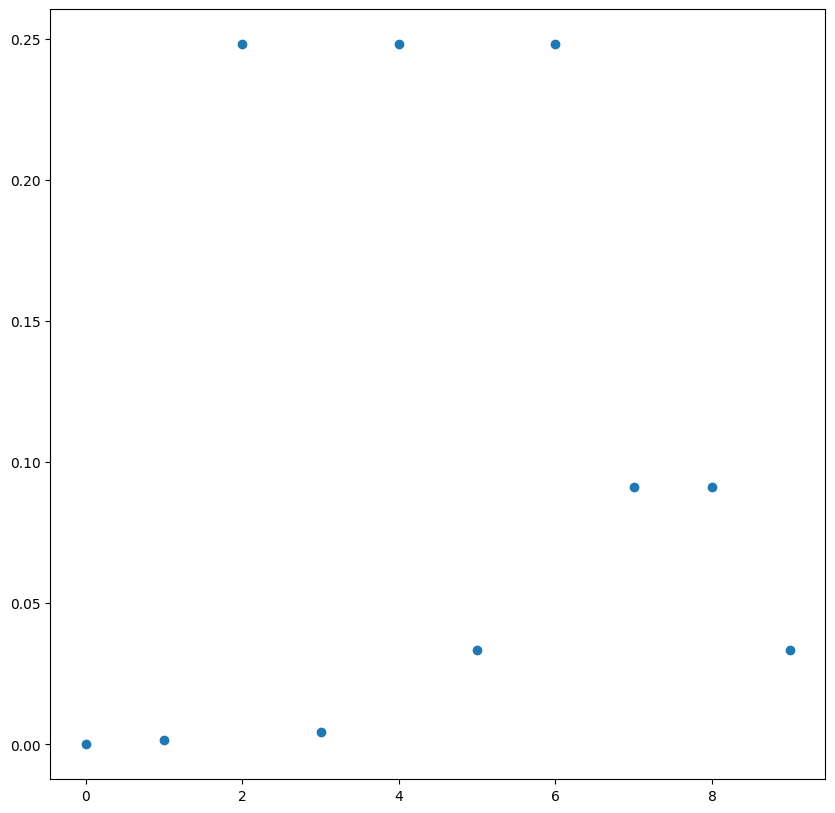

In [23]:
# The 'winner-take-most' shape: exponentiation makes the largest score dominate.
fig, ax = plt.subplots(figsize=(10,10))
ax.plot(softArr, marker='o', linestyle='None');

In [24]:
# The same softmax computed by hand: exp(x) / sum(exp(x)).
# (Library versions subtract max(x) first for numerical stability - same result,
# no overflow when the scores are large.)
## SoftMax

num = np.exp(arr)
den = np.sum(np.exp(arr))

softMax = num/den
softMax


array([3.06105781e-05, 1.67128094e-03, 2.48040084e-01, 4.54301260e-03,
       2.48040084e-01, 3.35685750e-02, 2.48040084e-01, 9.12488474e-02,
       9.12488474e-02, 3.35685750e-02])

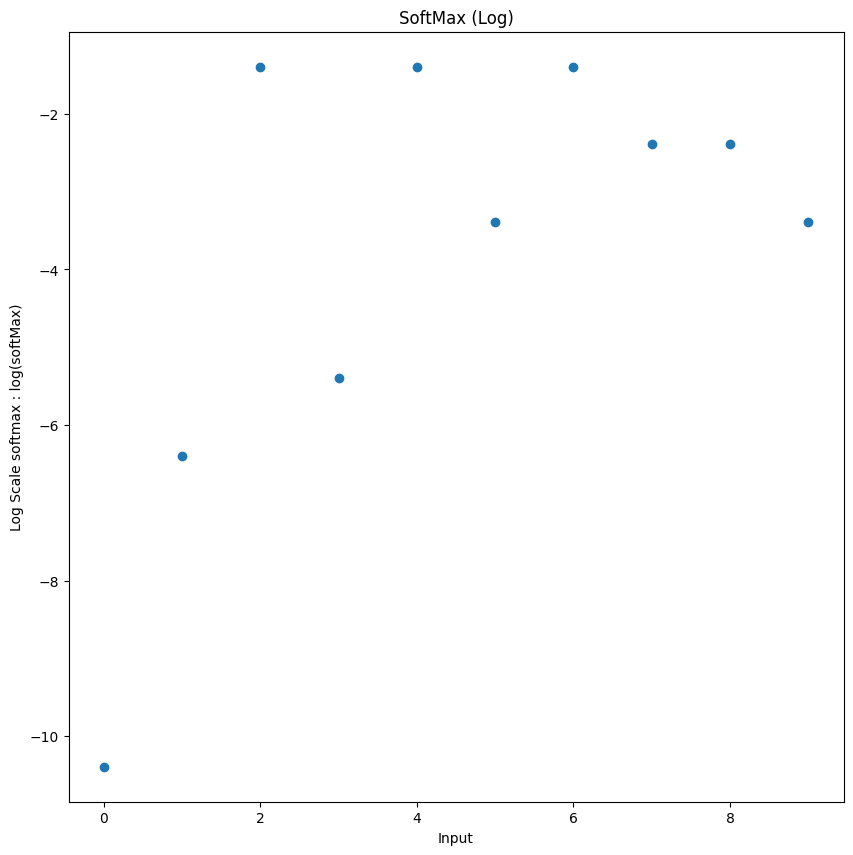

In [25]:
# Log of the softmax. Log turns the tiny probabilities into a readable linear
# scale - this is why losses are computed in log space (log_softmax + NLL).
import math
fig, ax = plt.subplots(figsize=(10,10))
ax.plot(np.log(softMax), marker='o', linestyle='None');
ax.set_title('SoftMax (Log)')
ax.set_xlabel('Input')
ax.set_ylabel('Log Scale softmax : log(softMax)');

### Using Pytorch for softmax

In [26]:
# The nn.Softmax layer form: create it once with the axis, then call it.
# Identical math to torch.softmax, but usable inside an nn.Sequential model.
import torch.nn as nn
softFun = nn.Softmax(dim=0)
softMax = softFun(torch.Tensor(arr))
softMax

tensor([3.0611e-05, 1.6713e-03, 2.4804e-01, 4.5430e-03, 2.4804e-01, 3.3569e-02,
        2.4804e-01, 9.1249e-02, 9.1249e-02, 3.3569e-02])

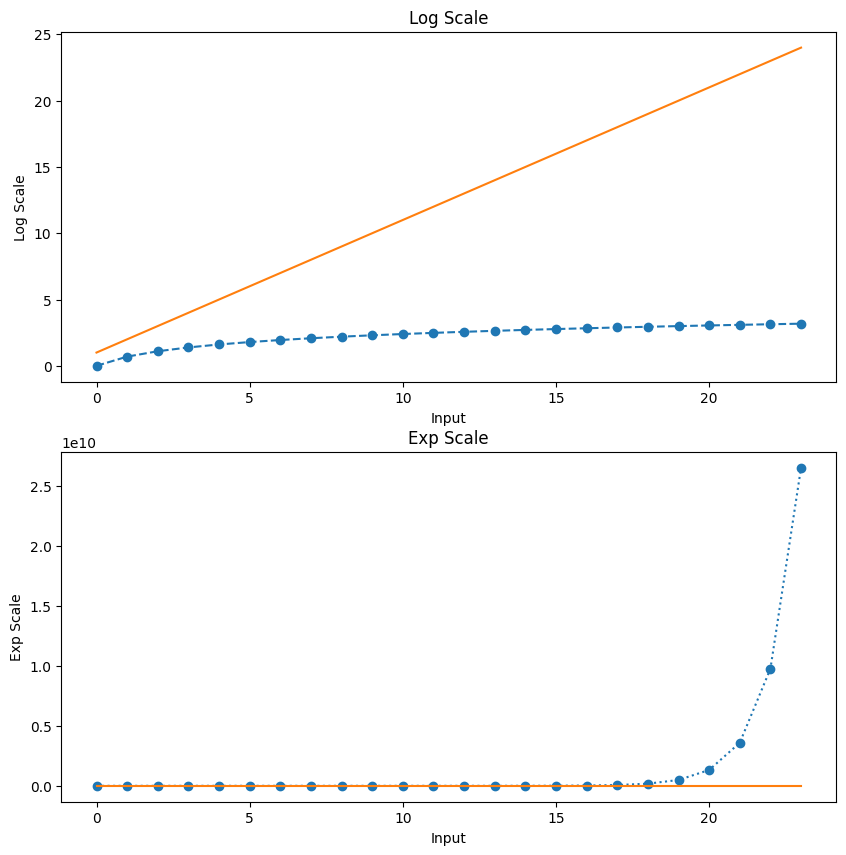

In [27]:
# Log vs exp intuition: log compresses large values, exp explodes them.
# Deep learning lives in log space to keep numbers in a workable range.
arr = []
for i in range(1,25):
  arr.append(i)

arr = np.array(arr)

logArr = np.log(arr)


fig, ax = plt.subplots(2,1,figsize=(10,10))

ax[0].plot(logArr, marker='o', linestyle="--");
ax[0].set_title('Log Scale')
ax[0].set_xlabel('Input')
ax[0].set_ylabel('Log Scale');
ax[0].plot(arr, linestyle="-");
ax[1].plot(np.exp(arr), marker='o', linestyle=":");
ax[1].set_title('Exp Scale')
ax[1].set_xlabel('Input')
ax[1].set_ylabel('Exp Scale');
ax[1].plot(arr, linestyle="-");


# 4) Entropy and Cross Entropy

### Entropy Formula

The entropy H(X) of a discrete random variable X with possible outcomes x₁, x₂, ..., xₙ and corresponding probabilities p(x₁), p(x₂), ..., p(xₙ) is given by:
$$
H(X) = - \sum_{i=1}^{n} p(x_i) \log_b p(x_i)
$$

**Where:**
- H(X): Entropy of the random variable X  
- p(xᵢ): Probability of outcome xᵢ  
- log_b: Logarithm with base `b` (e.g., base 2 for bits, base *e* for nats)  
- n: Total number of possible outcomes


In [28]:
# Entropy of a 2-outcome distribution: H = -sum p*log(p).
# High entropy = uncertain (50/50), zero entropy = certain. Here p=(0.25,0.75).
# Assuming the gender of a person is either male or female
male = 0.25
female = 0.75

prob = np.array([male, female])

entropy = 0
for i in prob:
  entropy += - (i * np.log(i))

f'{entropy:.2f}'


'0.56'

## **Cross Entropy**

---



### Cross-Entropy Formula

The cross-entropy between two probability distributions P and Q over the same set of events is given by:

$$
H(P, Q) = - \sum_{i=1}^{n} p(x_i) \log_b q(x_i)
$$

**Where:**
- H(P, Q): Cross-entropy between the true distribution P and the predicted distribution Q  
- p(xᵢ): True probability of event xᵢ (from distribution P)  
- q(xᵢ): Predicted probability of event xᵢ (from distribution Q)  
- log_b: Logarithm with base `b` (usually base 2 or natural log `ln`)  
- n: Number of classes or outcomes


In [29]:
# Cross-entropy H(p,q) = -sum p*log(q): the cost of predicting q when the truth
# is p. With one-hot p only the true class's term survives, so the loss is
# just -log(probability assigned to the correct class).
p = [0, 1]  # True distribution (one-hot)
q = [0.25, 0.75]  # Predicted probabilities

entropy = -((p[0] * np.log(q[0])) + (p[1] * np.log(q[1])))
print(entropy)

0.2876820724517809


### Using Pytorch

In [30]:
# PyTorch equivalent. Note the argument order: F.binary_cross_entropy(input, target)
# takes PREDICTIONS first, TARGETS second - the reverse of the math notation.
import torch.nn.functional as F

X = torch.Tensor(p)
Y = torch.Tensor(q)

loss=F.binary_cross_entropy(Y,X)
round(loss.item(),4)


0.2877

# 5) Min/Max and ArgMin/ArgMax


---

##  `min`, `max`, `argmin`, and `argmax` in Math & Python

---

## 🔹 Math Definitions

- **Minimum value:**
  $$
  \min_x f(x) \Rightarrow \text{Smallest value of } f(x)
  $$

- **Maximum value:**
  $$
  \max_x f(x) \Rightarrow \text{Largest value of } f(x)
  $$

- **Argument of minimum:**
  $$
  \arg\min_x f(x) \Rightarrow x \text{ such that } f(x) \text{ is minimized}
  $$

- **Argument of maximum:**
  $$
  \arg\max_x f(x) \Rightarrow x \text{ such that } f(x) \text{ is maximized}
  $$

---

In [31]:
# min/max return the VALUE, argmin/argmax return the INDEX of that value.
# Using Numpy


arr = np.random.randint(0,10,size=(10))
arr

array([0, 8, 4, 2, 3, 6, 8, 9, 5, 7])

In [32]:
np.min(arr), np.max(arr), np.argmin(arr), np.argmax(arr)

(np.int64(0), np.int64(9), np.int64(0), np.int64(7))

In [33]:
# Same functions on a matrix.
# In matrix

arr = np.random.randint(0,10,size=(3,3))
arr

array([[1, 7, 1],
       [8, 6, 0],
       [2, 8, 4]])

In [34]:
# With no axis given, NumPy flattens first - so the index is into the
# flattened array (row-major), not a (row, col) pair.
# in the whole matrix
min = np.min(arr)
max = np.max(arr)

minIndex = np.argmin(arr)
maxIndex = np.argmax(arr)

min, max, minIndex, maxIndex

(np.int64(0), np.int64(8), np.int64(5), np.int64(3))

In [35]:
# axis=1 collapses columns -> one result per ROW.
# axis=0 collapses rows    -> one result per COLUMN.
# Rule of thumb: the axis you name is the one that disappears.
minRow = np.min(arr, axis=1) # Use axis =1 for row, and axis=0 for col.
maxRow = np.max(arr, axis=1)

minCol = np.min(arr, axis=0)
maxCol = np.max(arr, axis=0)

minRow, maxRow, minCol, maxCol


(array([1, 0, 2]), array([7, 8, 8]), array([1, 6, 0]), array([8, 8, 4]))

In [36]:
# Same axis rule for the arg* variants: indices are within the collapsed axis.
minIndexRow = np.argmin(arr, axis=1)
maxIndexRow = np.argmax(arr, axis=1)

minIndexCol = np.argmin(arr, axis=0)
maxIndexCol = np.argmax(arr, axis=0)

minIndexRow, maxIndexRow, minIndexCol, maxIndexCol

(array([0, 2, 0]), array([1, 0, 1]), array([0, 1, 1]), array([1, 2, 2]))

### Using PyTorch

In [37]:
# The PyTorch versions behave the same way.
arr = torch.randint(0,10,size=(3,3))
arr

tensor([[1, 4, 2],
        [1, 5, 7],
        [4, 7, 0]])

In [38]:
min = torch.min(arr)
max = torch.max(arr)

minIndex = torch.argmin(arr)
maxIndex = torch.argmax(arr)

min, max, minIndex, maxIndex

(tensor(0), tensor(7), tensor(8), tensor(5))

In [39]:
# torch.min/max with an axis return a named tuple (values, indices) - unlike
# NumPy, you get both in one pass.
## Using in an axis


rowMin = torch.min(arr, axis=1)
rowMax = torch.max(arr, axis=1)

colMin = torch.min(arr, axis=0)
colMax = torch.max(arr, axis=0)


rowMin # Returns a special type called as torch.return_types.min() : this a tuple with both values and indexes

torch.return_types.min(
values=tensor([1, 1, 0]),
indices=tensor([0, 0, 2]))

In [40]:
rowMin.values, rowMin.indices

(tensor([1, 1, 0]), tensor([0, 0, 2]))

In [41]:
colMax

torch.return_types.max(
values=tensor([4, 7, 7]),
indices=tensor([2, 2, 1]))

In [42]:
colMax.values, colMax.indices

(tensor([4, 7, 7]), tensor([2, 2, 1]))


# 6) 📊 Mean and Variance

---

## 🧠 Mean (Expected Value)

- **Sample Mean**  
  $$
  \mu = \frac{1}{n} \sum_{i=1}^{n} x_i
  $$

- **Mean for a Discrete Random Variable**  
  $$
  \mathbb{E}[X] = \sum_{i} x_i \cdot P(x_i)
  $$

- **Mean for a Continuous Random Variable**  
  $$
  \mathbb{E}[X] = \int_{-\infty}^{\infty} x \cdot f(x) \, dx
  $$

---

## 📈 Variance

- **Sample Variance**  
  $$
  \sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2
  $$

- **Variance of a Discrete Random Variable**  
  $$
  \text{Var}(X) = \sum_{i} (x_i - \mathbb{E}[X])^2 \cdot P(x_i)
  $$

- **Variance of a Continuous Random Variable**  
  $$
  \text{Var}(X) = \int_{-\infty}^{\infty} (x - \mathbb{E}[X])^2 \cdot f(x) \, dx
  $$

- **Alternative Formula**  
  $$
  \text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2
  $$



In [43]:
# Mean over every element (no dim argument = reduce everything to a scalar).
arr = torch.rand(2,3)
torch.mean(arr)

tensor(0.5717)

## Seeding

In [44]:
# Seeding makes runs reproducible. Set it before any random init if you want
# to compare two models fairly - otherwise weight noise confounds the result.
torch.manual_seed(42)
torch.rand(3,3)

tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])

## T Test

In [50]:
# Two-sample t-test: the tool for "is model A really better than model B, or is
# this run-to-run noise?" Used later to compare accuracies across repeated runs.
import scipy.stats as stats

arr = np.random.randn(10)
arr2 = np.random.randn(2)

stats.ttest_ind(arr,arr2)

TtestResult(statistic=np.float64(-0.36474771011574997), pvalue=np.float64(0.7228951824775902), df=np.float64(10.0))